# Multi-Class SVM Classification

Uses optimal hyperparameters:
- Kernel: RBF
- C: 100
- Gamma: 1.0

In [10]:
import os
import ee
import geemap
from dotenv import load_dotenv
import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))

os.makedirs('../../assets', exist_ok=True)

In [11]:
campus_geojson = {
    "type": "Polygon",
    "coordinates": [
        [
            [80.01710357666015, 23.173962177472703],
            [80.03259601593017, 23.165361215115187],
            [80.03654422760009, 23.172502420044232],
            [80.026802444458,   23.181694681000845],
            [80.01542987823485, 23.176960548201308],
        ]
    ]
}
campus = ee.Geometry(campus_geojson)

def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate('2025-03-01', '2025-04-30')
      .filterBounds(campus)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 15))
      .map(mask_s2_clouds)
)
composite = dataset.median().clip(campus)

ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
ndwi = composite.normalizedDifference(['B3', 'B8']).rename('NDWI')
ndbi = composite.normalizedDifference(['B11', 'B8']).rename('NDBI')
savi = composite.expression(
    '1.5 * (NIR - RED) / (NIR + RED + 0.5)',
    {'NIR': composite.select('B8'), 'RED': composite.select('B4')}
).rename('SAVI')

composite = composite.addBands([ndvi, ndwi, ndbi, savi])
bands = ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDWI', 'NDBI', 'SAVI']

In [12]:
water     = ee.FeatureCollection('users/cosypix/water_points')
forest    = ee.FeatureCollection('users/cosypix/forest_points')
soil      = ee.FeatureCollection('users/cosypix/soil_points')
buildings = ee.FeatureCollection('users/cosypix/building_points')

class_names = ['Forest', 'Water', 'Buildings', 'Soil']
class_collections = [forest, water, buildings, soil]

print('--- Points per Class ---')
total_points = 0
for name, fc in zip(class_names, class_collections):
    count = fc.size().getInfo()
    total_points += count
    print(f'{name}: {count}')
print(f'Total Points: {total_points}')
print()

all_points = water.merge(forest).merge(soil).merge(buildings)

training = (
    composite.select(bands)
             .sampleRegions(
                 collection=all_points,
                 properties=['label'],
                 scale=10
             )
             .filter(ee.Filter.notNull(bands + ['label']))
             .randomColumn('random', 42)
)

train_set = training.filter(ee.Filter.lt('random', 0.7))
test_set  = training.filter(ee.Filter.gte('random', 0.7))
print("Train Set Size:", train_set.size().getInfo())
print("Test Set Size:", test_set.size().getInfo())

--- Points per Class ---
Forest: 240
Water: 100
Buildings: 180
Soil: 240
Total Points: 760

Train Set Size: 544
Test Set Size: 216


Overall Accuracy: 0.9074074074074074
Kappa Coefficient: 0.8724836176869946

--- Class-wise Accuracy ---
Forest: 0.9155
Water: 0.9643
Buildings: 0.9333
Soil: 0.8611



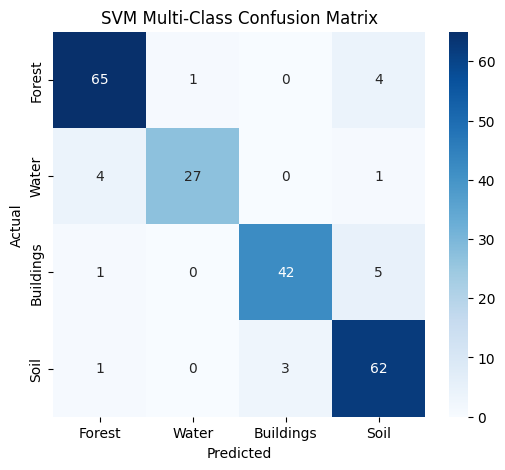

In [13]:
svm_classifier = ee.Classifier.libsvm(
    kernelType='RBF',
    gamma=1.0,
    cost=100.0
).train(
    features=train_set,
    classProperty='label',
    inputProperties=bands
)

test_classified = test_set.classify(svm_classifier)
confusion_matrix = test_classified.errorMatrix('label', 'classification')

print('Overall Accuracy:', confusion_matrix.accuracy().getInfo())
print('Kappa Coefficient:', confusion_matrix.kappa().getInfo())

print('\n--- Class-wise Accuracy ---')
consumers_acc = confusion_matrix.consumersAccuracy().getInfo()

for i, name in enumerate(class_names):
    # Safely access the 0th row, then the i-th column
    if i < len(consumers_acc[0]):
        acc = consumers_acc[0][i] if consumers_acc[0][i] is not None else 0.0
    else:
        acc = 0.0
        
    print(f'{name}: {acc:.4f}')

print()

cm_array = confusion_matrix.array().getInfo()

plt.figure(figsize=(6, 5))
sns.heatmap(cm_array, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Multi-Class Confusion Matrix')
plt.savefig('../../assets/multi_svm_cm.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
classified = composite.select(bands).classify(svm_classifier)
classified_smooth = classified.focalMode(radius=1, kernelType='square', units='pixels')

class_palette = ['00FF00', '0000FF', 'FF0000', 'D2B48C']

Map = geemap.Map(center=[23.174, 80.026], zoom=15)
Map.addLayer(composite, {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 0.3}, 'RGB Composite')
Map.addLayer(classified_smooth, {'min': 0, 'max': 3, 'palette': class_palette}, 'KNN Classification')

legend_dict = {
    'Forest (0)':     '00FF00',
    'Water (1)':      '0000FF',
    'Buildings (2)':  'FF0000',
    'Soil (3)':       'D2B48C'
}
Map.add_legend(title='Land Cover', legend_dict=legend_dict)
Map.addLayer(campus, {}, 'Campus Boundary')
Map

Map(center=[23.174, 80.026], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

In [15]:
area_image = ee.Image.pixelArea().addBands(classified_smooth)
areas = area_image.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=campus,
    scale=10,
    maxPixels=1e10
)

area_data = areas.getInfo()['groups']
print("--- Class Areas (Hectares) ---")
for entry in area_data:
    ha = entry['sum'] / 10000
    print(f"{class_names[entry['class']]}: {ha:.2f} ha")

--- Class Areas (Hectares) ---
Forest: 92.59 ha
Water: 3.72 ha
Buildings: 17.40 ha
Soil: 85.35 ha
